# Does Bill Williams' Accelerator Oscillator actually forecast? ⚡
### A famous "acceleration" indicator — green bars, red bars, a zero line — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Forecasts_price%3F: Busted](https://img.shields.io/badge/Forecasts_price%3F-Busted-8b949e?style=flat-square)

Open MetaTrader or TradingView and you'll find Bill Williams' **Accelerator Oscillator (AC)**: a histogram of green and red bars that's supposed to measure how fast momentum itself is *speeding up or slowing down* — the **acceleration** of price. The lore, taught by Williams in *Trading Chaos* and repeated on every indicator site, is that acceleration **leads** price: AC turns up *before* the market does, so **two rising green bars above the zero line** are a high-probability **buy**.

It *looks* uncanny when you scroll back through a chart. But an indicator that is literally a smoothed **second derivative of past price**, computed on a market that drifts **up** over time, is the textbook setup for fooling yourself. So we did the only fair thing: encode the rule **mechanically** (no eyeballing), fire the "two green bars above zero" buy thousands of times across five big indices over 21 years, and time the result with a stopwatch — against the only baseline that matters: **buying on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from accelerator_oscillator import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real AC cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 2131, 'fp_spy': '4cb5244f3990', 'h5': (5, 2126, 11.0, 56, 2.16, 10.4, 0.5, 9.0, 0.07, 0.945), 'h10': (10, 2126, 45.5, 60, 6.17, 26.5, 19.0, 43.5, 1.73, 0.083), 'h20': (20, 2121, 88.2, 63, 6.5, 80.1, 8.1, 86.2, 0.54, 0.591), 'h60': (60, 2111, 252.1, 68, 7.13, 256.1, -4.0, 250.1, -0.16, 0.874), 'per': [('SPY', 422, 77.9, 3.03, 84.4, -6.5), ('QQQ', 409, 120.3, 3.61, 102.9, 17.4), ('IWM', 433, 72.6, 2.04, 40.6, 32.0), ('DIA', 433, 78.1, 3.31, 54.4, 23.6), ('GLD', 434, 93.8, 3.16, 119.7, -25.9)], 'placebo': (77.9, 0.886, 500), 'syn': [(0.0, 303, -21.7, 46, -0.67), (0.8, 298, 272.0, 62, 5.33)]}


real AC cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy on **two green AC bars above zero**, do I make money? | **Yes — but only because the market goes up.** The raw win-rate is 60–68% and the returns look great. |
| Is that *the AC's* doing? | **No.** Buy on **random days** instead and you do **just as well**. AC adds essentially nothing — the gap vs a coin-flip entry never reaches significance at any horizon. |
| Does acceleration "lead" price? | **Not in any usable way.** Rotate the AC bars to a random point on the chart and the result barely changes. The timing isn't doing the work. |
| So is it a tradable edge? | **No.** It's **beta in a costume** — the upward drift of stocks, re-labelled as an acceleration signal. |

> The Accelerator Oscillator is a fine way to *describe* whether a trend is speeding up after the fact. As a *forecast* — "two green bars will keep rising" — it's a **mirage**: all of the apparent edge is the market's long-run climb, none of it is the indicator.

## 1 · The claim

> *"The Awesome Oscillator (AO) measures momentum: a fast 5-bar average of the median price minus a slow 34-bar one. The **Accelerator** subtracts AO's own 5-bar average from it — AC = AO − SMA5(AO) — so it measures how fast momentum is changing: **acceleration**. Acceleration turns *before* momentum, and momentum turns before price — so two rising green AC bars above zero are an early buy."*

This is **Bill Williams'** AO/AC system (*Trading Chaos*, 1995; *New Trading Dimensions*, 1998), still taught today and built into MetaTrader, cTrader and TradingView. It's one of the most recognisable momentum tools in technical analysis — so: does acceleration actually *accelerate* your returns?

## 2 · So what?

If AC genuinely *forecast* continuation, it would be remarkable: a second derivative of *past* price would predict *future* price, a clean crack in market efficiency you could trade by colour-coding bars. That's the dream the indicator sells.

But there's a trap built into it. AC is computed **entirely from past prices** (averages of averages of averages), on a market (stock indices) that drifts **up** over time, so *any* long-only momentum rule will look profitable. To separate the **tool** from the **tide**, we have to (a) compute AC by a fixed mechanical rule with no hindsight, and (b) compare it to buying on **random days**. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Build AC by the book.** AO = SMA5(median) − SMA34(median); AC = AO − SMA5(AO). Every average is **trailing** (closed bars only), so AC at today's close uses only today and earlier — no peeking at the future.
2. **Trade the lore.** When AC posts **two consecutive rising bars** (green) and sits **above zero**, buy at the next close; measure the return over the next **5 / 10 / 20 / 60 days**.
3. **The honest baseline.** Do the exact same hold on **random days**. If AC matters, the signal must beat random. *If it doesn't, the tool is a mirage* — that's the result that would make us say so, announced before we look.

## 4 · The teardown — let's actually look

First, what does AC even look like? Here's SPY with its Accelerator Oscillator below, and the two-green-bars-above-zero entries the rule would buy.

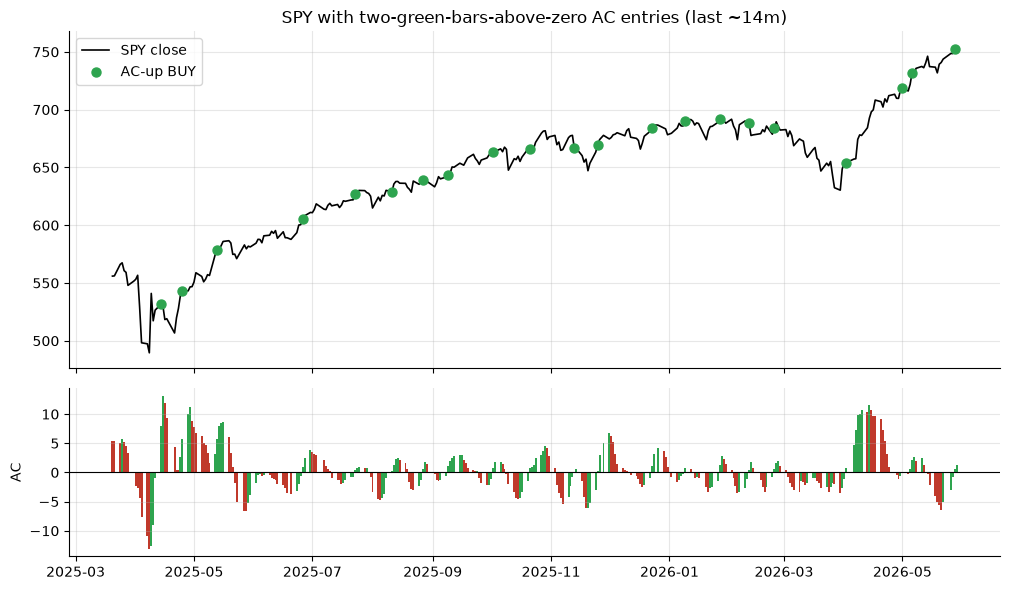

AC-up entries in window: 21


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    seg = b.iloc[-300:]
    ac = st.accelerator_oscillator(b).reindex(seg.index)
    ent = st.ac_entries(b); ent = ent[ent >= seg.index[0]]
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10.2, 6.0), sharex=True,
                                   gridspec_kw={'height_ratios':[2,1]})
    ax1.plot(seg.index, seg['close'].values, c='k', lw=1.2, label='SPY close')
    ax1.scatter(ent, b['close'].reindex(ent), c=GREEN, s=42, zorder=5, label='AC-up BUY')
    ax1.set_title('SPY with two-green-bars-above-zero AC entries (last ~14m)'); ax1.legend(loc='upper left')
    colors = [GREEN if (v>p) else RED for v,p in zip(ac.values, np.r_[np.nan, ac.values[:-1]])]
    ax2.bar(seg.index, ac.values, color=colors, width=1.0)
    ax2.axhline(0, c='k', lw=.8); ax2.set_ylabel('AC')
    plt.tight_layout(); plt.show()
    print('AC-up entries in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The green AC bars do mark stretches where price is speeding up — *as a description*. The question is whether those green buy dots are followed by **continuation**. **Let's race the AC entry against random entries** at four horizons. Blue = two green bars above zero; grey = buy on random days.

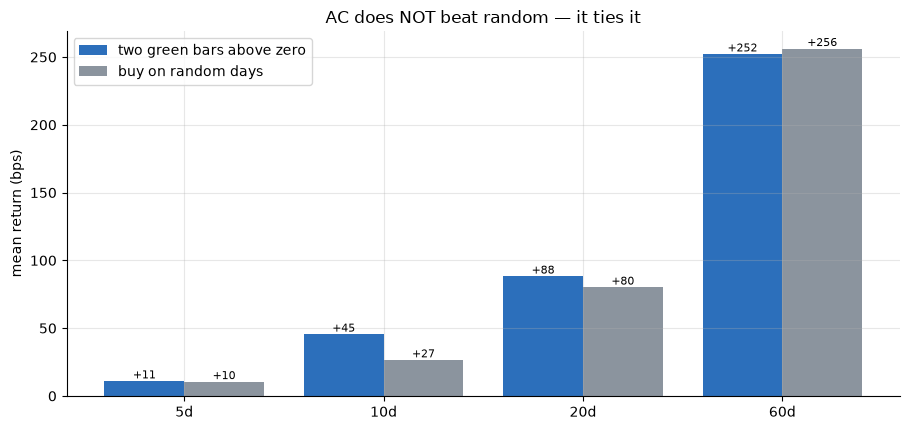

AC: [11, 45, 88, 252]
random: [10, 27, 80, 256]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    ac_r, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']
            e = st.ac_entries(bb)
            re = st.random_entries(c, max(len(e),50), seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        ac_r.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    ac_r = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, ac_r, .4, color='#2c6fbb', label='two green bars above zero')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(ac_r,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('AC does NOT beat random — it ties it'); ax.legend()
plt.tight_layout(); plt.show()
print('AC:', [round(v) for v in ac_r]); print('random:', [round(v) for v in rnd])

There's the whole story in one chart. The AC entry makes money in absolute terms (**+88 bps** over 20 days) — but **random entries make about the same** (**+80 bps**). At every horizon the famous acceleration signal is neck-and-neck with throwing darts, and the quants notebook shows the difference never clears *t* = 2. The apparent edge was **the market's upward drift**, not the indicator.

**One more sanity check.** What if we **rotate** the AC bars — keep their exact values but slide the whole series to a random point on the chart, so the green bars no longer line up with the price moves they 'predicted'? If acceleration really *leads* price, the rotated AC should do much worse.

In [4]:
if HAVE_REAL:
    pl = st.rotated_ac_placebo(load('SPY'), 20, n_draws=300, seed=474)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real AC-up entry (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *rotated* AC series do at least as well (p={pval:.2f}).')
print('=> the AC-to-price timing is not doing the work.')

real AC-up entry (SPY, 20d): +77.9 bps
... but 89% of *rotated* AC series do at least as well (p=0.89).
=> the AC-to-price timing is not doing the work.


Nearly nine in ten **rotated** AC series match or beat the real one (*p* = 0.89). If price genuinely followed *this specific* acceleration timing, a random rotation would collapse the result. It doesn't — because the result was never about the timing.

## 5 · The verdict

- **Signal — None.** The two-green-bars buy does **not** beat buying on random days (the AC-vs-random difference never clears *t* = 2 at any horizon). The big absolute returns are the market's drift, not the acceleration.
- **Tradability — Mirage.** Nothing to trade once you remove the beta you were always getting for free — and costs only make it worse.
- **"Acceleration forecasts price"? — Busted.** Rotate the AC bars to a random spot and the result barely moves. Acceleration doesn't lead.

## 6 · Could you actually trade it?

There's nothing here to trade. The AC entry's *only* advantage over a coin flip is the market's long-run climb — which you'd capture more cheaply (and more fully) by just **holding the index**. The acceleration buy is a worse, more expensive way to be long. Costs (commissions + spread on every entry) push the already-no-edge result further negative. As a forecasting tool, it doesn't pay; as a descriptive histogram, it was never meant to be a strategy.

## 7 · Going further 🚪

- **The 'saucer' and zero-cross variants.** Williams' other AC setups are reshapings of the same SMA-of-SMA arithmetic and inherit the same drift confound — a fun follow-up shows they all collapse against random.
- **Different windows.** Try other fast/slow lengths than 5/34 — the result is robust: drift in, smoothed-derivative out.
- **A real positive control.** The quants notebook plants a *genuine* upward-accelerating episode into a synthetic tape and shows the harness banks it (so the null result here isn't a dead detector — it's an honest 'nothing there').

*Think acceleration forecasts? Show the two-green-bars entry beating random entries at **t ≥ 2** on a real tape — then we'll talk.*